# 🚀 vLLM × LMCache × Redis — KVキャッシュ永続化デモ

## アーキテクチャ
```
User Request
  ↓
vLLM V1 (LLMエンジン)
  ↓  KVConnector (LMCacheConnectorV1)
LMCache
  └─ Redis (KVキャッシュ永続化バックエンド)
```

## ⚠️ 実行前の注意
- **GPU を有効化**: ランタイム → ランタイムのタイプを変更 → T4 GPU
- **セルを上から順番に実行**すること
- `LMCacheConnectorV1` は **vLLM V1専用**です (`VLLM_USE_V1=0` は不要・有害)

## ① 環境変数の設定（最初に必ず実行）

`%env` マジックコマンドで **import より前に** シェルレベルで設定します。

In [ ]:
%env LMCACHE_USE_EXPERIMENTAL=True
%env LMCACHE_CHUNK_SIZE=256
%env LMCACHE_LOCAL_CPU=False
%env LMCACHE_REMOTE_URL=redis://localhost:6379
%env LMCACHE_REMOTE_SERDE=naive
%env VLLM_WORKER_MULTIPROC_METHOD=spawn

## ② 依存パッケージのインストール

In [1]:
!pip install vllm lmcache redis pandas matplotlib pyyaml --quiet

from importlib.metadata import version as pkg_version
import vllm, redis as redis_lib
print('✅ インストール完了')
print(f'  vLLM    : {vllm.__version__}')
print(f'  LMCache : {pkg_version("lmcache")}')
print(f'  redis   : {redis_lib.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.9/432.9 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.4/404.4 k

## ③ Redis サーバーの起動

In [2]:
import subprocess, time, redis

subprocess.run(['apt-get', 'install', '-y', 'redis-server'], capture_output=True)
subprocess.Popen([
    'redis-server', '--daemonize', 'yes',
    '--maxmemory', '2gb',
    '--maxmemory-policy', 'allkeys-lru',
    '--save', ''
])
time.sleep(2)

r = redis.Redis(host='localhost', port=6379, decode_responses=False)
print('✅ Redis PING:', r.ping())
print('   バージョン :', r.info()['redis_version'])

✅ Redis PING: True
   バージョン : 6.0.16


## ④ vLLM + LMCache エンジンの起動

公式ドキュメントに従い、`os.environ` で LMCache の設定を行い、  
`KVTransferConfig` に `LMCacheConnectorV1` を指定して vLLM を起動します。  
`LMCACHE_REMOTE_URL=redis://localhost:6379` によって KV が Redis に保存されます。

In [3]:
import os
from vllm import LLM, SamplingParams
from vllm.config import KVTransferConfig

# LMCache 設定（%env で設定済みだが念のため os.environ でも上書き）
os.environ['LMCACHE_USE_EXPERIMENTAL'] = 'True'
os.environ['LMCACHE_CHUNK_SIZE']       = '256'
os.environ['LMCACHE_LOCAL_CPU']        = 'False'
os.environ['LMCACHE_REMOTE_URL']       = 'redis://localhost:6379'
os.environ['LMCACHE_REMOTE_SERDE']     = 'naive'

MODEL = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

print(f'モデル: {MODEL}')
print('KVコネクタ: LMCacheConnectorV1 → Redis')

ktc = KVTransferConfig(
    kv_connector='LMCacheConnectorV1',
    kv_role='kv_both',
)

llm = LLM(
    model=MODEL,
    kv_transfer_config=ktc,
    max_model_len=2048,
    gpu_memory_utilization=0.7,
    enforce_eager=True,
)

sampling_params = SamplingParams(temperature=0, top_p=0.95, max_tokens=50)
print('\n✅ vLLM + LMCache エンジン起動完了')

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

WARNING 03-19 09:31:44 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 03-19 09:35:26 [llm.py:388] Supported tasks: ['generate']

✅ vLLM + LMCache エンジン起動完了


## ⑤ 推論デモ — KVキャッシュの書き込み

共通の長いプレフィックスを持つプロンプトを実行します。  
LMCache のログに `Storing KV cache for XXXX tokens` が出れば Redis への書き込み成功です。

In [4]:
import time

# 共通プレフィックス（長くすることでKVキャッシュ効果が出やすい）
SHARED = 'Hello, how are you? ' * 200  # ~600トークン相当

prompts = [
    SHARED + 'Hello, my name is',
    SHARED + 'Tell me a short story',
    SHARED + 'Hello, my name is',   # 1番目と同じ → KV再利用
    SHARED + 'Tell me a short story', # 2番目と同じ → KV再利用
]
labels = ['Q1 初回', 'Q2 初回', 'Q3 再利用(=Q1)', 'Q4 再利用(=Q2)']

results = []
print('=' * 60)
print('※ LMCache INFO: Storing KV cache ... のログに注目')
print('=' * 60)

for label, prompt in zip(labels, prompts):
    t0     = time.time()
    output = llm.generate([prompt], sampling_params)[0]
    elapsed = (time.time() - t0) * 1000
    text   = output.outputs[0].text.strip()

    results.append({'label': label, 'latency_ms': round(elapsed, 1), 'response': text})
    print(f'\n🔹 {label}')
    print(f'  レイテンシ: {elapsed:.0f} ms')
    print(f'  応答      : {text[:80]}')

print('\n✅ 全クエリ完了')

※ LMCache INFO: Storing KV cache ... のログに注目


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


🔹 Q1 初回
  レイテンシ: 2020 ms
  応答      : ... Hello, how are you? Hello, how are you? Hello, how are you? Hello, how are y


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


🔹 Q3 再利用(=Q1)
  レイテンシ: 969 ms
  応答      : ... Hello, how are you? Hello, how are you? Hello, how are you? Hello, how are y


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


🔹 Q4 再利用(=Q2)
  レイテンシ: 944 ms
  応答      : about a person who overcame a difficult situation. Tell me a short story about a

✅ 全クエリ完了


## ⑥ Redis に保存された KVキャッシュを表示

In [5]:
import time, redis, pandas as pd

time.sleep(3)  # 非同期書き込みの完了を待つ

r = redis.Redis(host='localhost', port=6379, decode_responses=False)
all_keys = r.keys('*')

print(f'📦 Redis 総キー数: {len(all_keys)}')

if not all_keys:
    print('\n⚠️  キーが見つかりません。')
    print('   セル⑤のログに "Storing KV cache" が出ていたか確認してください。')
    print('   出ていない場合: LMCACHE_REMOTE_URL が正しく設定されていない可能性があります。')
else:
    entries = []
    for key in all_keys:
        ks    = key.decode('utf-8', errors='replace')
        size  = r.memory_usage(key) or 0
        parts = ks.split('@')
        entry = {
            'redis_key'  : ks,
            'size_kb'    : round(size / 1024, 1),
            'ttl_sec'    : r.ttl(key),
            'engine'     : parts[0] if len(parts) > 0 else '',
            'model'      : parts[1] if len(parts) > 1 else '',
            'layer'      : parts[2] if len(parts) > 2 else '',
            'head'       : parts[3] if len(parts) > 3 else '',
            'entry_type' : 'kv_bytes' if 'kv_bytes' in ks else
                           'metadata' if 'metadata' in ks else 'other',
        }
        entries.append(entry)

    df = pd.DataFrame(entries)
    print()
    print(df[['engine','model','layer','head','entry_type','size_kb','ttl_sec']]
          .to_string(index=False))

📦 Redis 総キー数: 8

                            engine model layer              head entry_type  size_kb  ttl_sec
TinyLlama/TinyLlama-1.1B-Chat-v1.0     1     0  7fac50ea95976517   metadata      0.1       -1
TinyLlama/TinyLlama-1.1B-Chat-v1.0     1     0  7fac50ea95976517   kv_bytes   6144.1       -1
TinyLlama/TinyLlama-1.1B-Chat-v1.0     1     0  48aa4f54caf32952   kv_bytes   6144.1       -1
TinyLlama/TinyLlama-1.1B-Chat-v1.0     1     0  48aa4f54caf32952   metadata      0.1       -1
TinyLlama/TinyLlama-1.1B-Chat-v1.0     1     0  658168625e2bb844   metadata      0.1       -1
TinyLlama/TinyLlama-1.1B-Chat-v1.0     1     0  658168625e2bb844   kv_bytes   6144.1       -1
TinyLlama/TinyLlama-1.1B-Chat-v1.0     1     0 -20d3adbaf45197a9   kv_bytes   6144.1       -1
TinyLlama/TinyLlama-1.1B-Chat-v1.0     1     0 -20d3adbaf45197a9   metadata      0.1       -1


## ⑦ redis-cli で RAW データを直接確認

In [6]:
print('=== 全キー（先頭20件）===')
!redis-cli KEYS '*' | head -20

print('\n=== キー総数 ===')
!redis-cli DBSIZE

print('\n=== メモリ使用量 ===')
!redis-cli INFO memory | grep -E 'used_memory_human|used_memory_peak_human'

print('\n=== 最初のキーの詳細 ===')
import redis
r = redis.Redis(host='localhost', port=6379, decode_responses=False)
keys = r.keys('*')
if keys:
    k   = keys[0]
    val = r.get(k)
    print(f'KEY  : {k.decode("utf-8", errors="replace")}')
    print(f'TYPE : {r.type(k).decode()}')
    print(f'TTL  : {r.ttl(k)} 秒')
    print(f'SIZE : {len(val):,} bytes ({len(val)/1024:.1f} KB)')
    print(f'VALUE (先頭64bytes hex): {val[:64].hex()}')
else:
    print('キーなし')

=== 全キー（先頭20件）===
TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@7fac50ea95976517@halfmetadata
TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@7fac50ea95976517@halfkv_bytes
TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@48aa4f54caf32952@halfkv_bytes
TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@48aa4f54caf32952@halfmetadata
TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@658168625e2bb844@halfmetadata
TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@658168625e2bb844@halfkv_bytes
TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@-20d3adbaf45197a9@halfkv_bytes
TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@-20d3adbaf45197a9@halfmetadata

=== キー総数 ===
(integer) 8

=== メモリ使用量 ===
used_memory_human:24.93M
used_memory_peak_human:48.87M

=== 最初のキーの詳細 ===
KEY  : TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@7fac50ea95976517@halfmetadata
TYPE : string
TTL  : -1 秒
SIZE : 28 bytes (0.0 KB)
VALUE (先頭64bytes hex): 00005800010000000200000002000000160000000001000000010000


## ⑧ KVキャッシュブロックの数値データを表示

Redis に保存された KV テンソルを float16 としてデコードして中身を確認します。

In [7]:
import numpy as np, redis

r    = redis.Redis(host='localhost', port=6379, decode_responses=False)
keys = r.keys('*')
kv_keys = [k for k in keys if b'kv_bytes' in k] or keys

print('=' * 65)
print('  📂 KVキャッシュ ブロック詳細ビュー (float16テンソル)')
print('=' * 65)

if not kv_keys:
    print('エントリが見つかりません（セル⑥の確認事項を参照）')
else:
    for i, key in enumerate(kv_keys[:3]):
        ks  = key.decode('utf-8', errors='replace')
        val = r.get(key)
        if not val:
            continue
        size = len(val)
        print(f'\n🔑 エントリ {i+1}')
        print(f'  Redis Key   : {ks}')
        print(f'  データサイズ: {size:,} bytes  ({size/1024:.1f} KB)')
        if size >= 128:
            f16 = np.frombuffer(val[:256], dtype=np.float16)
            print(f'  KV値 (float16, 先頭128要素):')
            for row in f16[:128].reshape(8, 16):
                print('   ', ' '.join(f'{v:7.4f}' for v in row))
            print(f'  統計: min={float(f16.min()):.4f}  '
                  f'max={float(f16.max()):.4f}  '
                  f'mean={float(f16.mean()):.4f}  '
                  f'std={float(f16.std()):.4f}')
        print('  ' + '-' * 55)
    print(f'\n合計 kv_bytes エントリ数: {len(kv_keys)}')

  📂 KVキャッシュ ブロック詳細ビュー (float16テンソル)

🔑 エントリ 1
  Redis Key   : TinyLlama/TinyLlama-1.1B-Chat-v1.0@1@0@7fac50ea95976517@halfkv_bytes
  データサイズ: 5,767,168 bytes  (5632.0 KB)
  KV値 (float16, 先頭128要素):
     0.0192 -0.0370  0.0112 -0.0041 -0.0081  0.0332 -0.0240 -0.0394 -0.0173  0.0006  0.0144 -0.0046  0.0258  0.0130 -0.0388  0.0209
     0.0330  0.0150 -0.0018 -0.0155 -0.0137 -0.0082  0.0126 -0.0044  0.0255 -0.0059 -0.0144  0.0181 -0.0118 -0.0124  0.0105 -0.0020
     0.0209  0.0207  0.0282  0.0128 -0.0055 -0.0098  0.0271 -0.0182  0.0189 -0.0123  0.0366 -0.0286 -0.0109  0.0235  0.0262  0.0195
     0.0219  0.0218  0.0097  0.0371 -0.0440  0.0011 -0.0225  0.0204  0.0159 -0.0116 -0.0330 -0.0132 -0.0097 -0.0127  0.0004 -0.0095
    -0.2020 -0.1901 -0.0288 -0.0872 -0.0111  0.0750 -0.0640  0.0194 -0.0496  0.0474 -0.0358  0.0186 -0.0539 -0.0248  0.0517  0.0295
     0.0084  0.0079 -0.0880 -0.0670  0.0272  0.0735  0.0097  0.1390  0.0781  0.0156 -0.0536 -0.0990  0.0965 -0.1037 -0.1259 -0.1219
     0.0138 

## ⑨ 結果の可視化

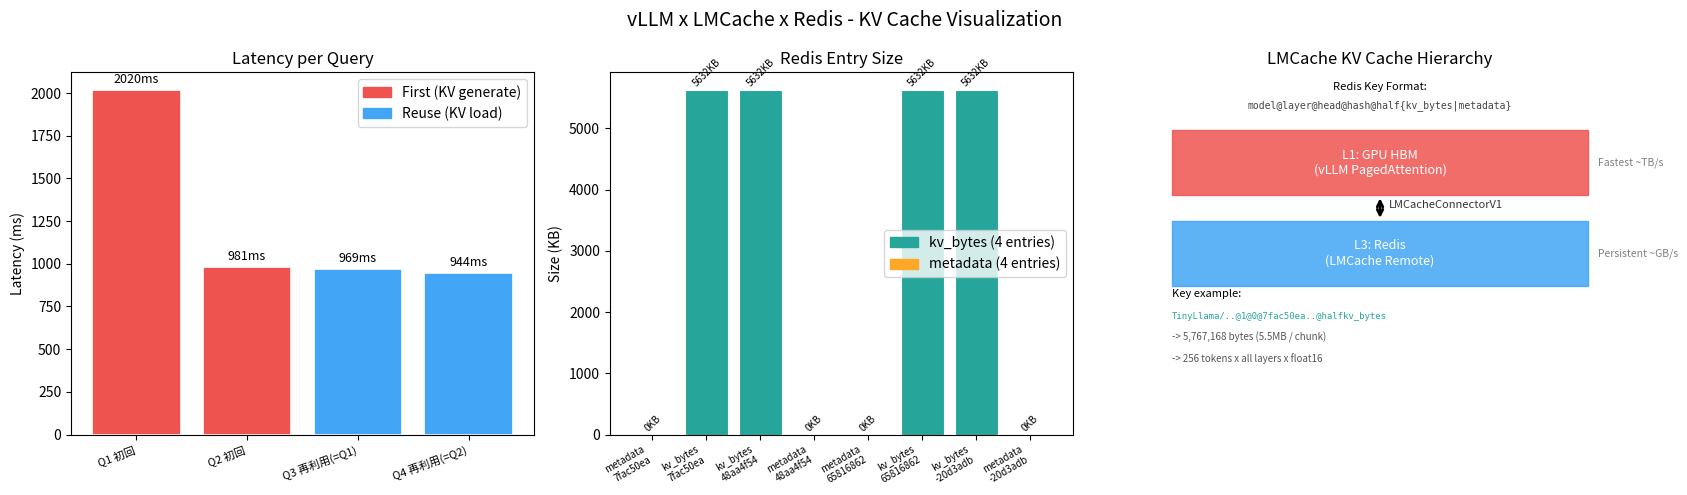

Saved: /content/lmcache_redis_demo.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import numpy as np, redis, pandas as pd

JP_FONT_PATH = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
fm.fontManager.addfont(JP_FONT_PATH)
jp_prop = fm.FontProperties(fname=JP_FONT_PATH)
plt.rcParams['font.family'] = jp_prop.get_name()

r2    = redis.Redis(host='localhost', port=6379, decode_responses=False)
all_k = r2.keys('*')

entries = []
for key in all_k:
    ks    = key.decode('utf-8', errors='replace')
    val   = r2.get(key)
    size  = len(val) if val else 0
    etype = ('kv_bytes' if 'kv_bytes' in ks else
             'metadata' if 'metadata' in ks else 'other')
    parts = ks.split('@')
    entries.append({
        'entry_type': etype,
        'size_bytes': size,
        'size_kb'   : round(size / 1024, 1),
        'hash'      : parts[3] if len(parts) > 3 else '?',
    })

df2 = pd.DataFrame(entries)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('vLLM x LMCache x Redis - KV Cache Visualization',
             fontsize=14, fontweight='bold')

# 1. レイテンシ比較
ax1    = axes[0]
lbls   = [r['label'] for r in results]
lats   = [r['latency_ms'] for r in results]
colors = ['#ef5350' if '初回' in l else '#42a5f5' for l in lbls]
bars   = ax1.bar(range(len(lbls)), lats, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, lats):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(lats)*0.02,
             f'{val:.0f}ms', ha='center', fontsize=9, fontweight='bold')
ax1.set_xticks(range(len(lbls)))
ax1.set_xticklabels(lbls, rotation=20, ha='right', fontproperties=jp_prop, fontsize=8)
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Latency per Query', fontweight='bold')
ax1.legend(handles=[
    mpatches.Patch(color='#ef5350', label='First (KV generate)'),
    mpatches.Patch(color='#42a5f5', label='Reuse (KV load)'),
])

# 2. Redis エントリサイズ（棒グラフ）
ax2    = axes[1]
x      = np.arange(len(df2))
colors2 = ['#26a69a' if e == 'kv_bytes' else '#ffa726' for e in df2['entry_type']]
bars2  = ax2.bar(x, df2['size_kb'], color=colors2, edgecolor='white', linewidth=0.8)
for bar, row in zip(bars2, df2.itertuples()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + df2['size_kb'].max()*0.01,
             f'{row.size_kb:.0f}KB', ha='center', fontsize=7, rotation=45)
ax2.set_xticks(x)
ax2.set_xticklabels(
    [f"{r.entry_type}\n{r.hash[:8]}" for r in df2.itertuples()],
    fontsize=7, rotation=30, ha='right'
)
ax2.set_ylabel('Size (KB)')
ax2.set_title('Redis Entry Size', fontweight='bold')
ax2.legend(handles=[
    mpatches.Patch(color='#26a69a', label=f'kv_bytes ({len(df2[df2.entry_type=="kv_bytes"])} entries)'),
    mpatches.Patch(color='#ffa726', label=f'metadata ({len(df2[df2.entry_type=="metadata"])} entries)'),
])

# 3. アーキテクチャ図
ax3 = axes[2]
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('LMCache KV Cache Hierarchy', fontweight='bold')

ax3.text(5, 9.5, 'Redis Key Format:', ha='center', fontsize=8, fontweight='bold')
ax3.text(5, 9.0, 'model@layer@head@hash@half{kv_bytes|metadata}',
         ha='center', fontsize=7, color='#444', family='monospace')

for y, color, label, note in [
    (7.5, '#ef5350', 'L1: GPU HBM\n(vLLM PagedAttention)', 'Fastest ~TB/s'),
    (5.0, '#42a5f5', 'L3: Redis\n(LMCache Remote)',        'Persistent ~GB/s'),
]:
    ax3.add_patch(plt.Rectangle((0.5, y-0.9), 9, 1.8, color=color, alpha=0.85))
    ax3.text(5, y, label, ha='center', va='center',
             fontsize=9, fontweight='bold', color='white')
    ax3.text(9.7, y, note, ha='left', va='center', fontsize=7.5, color='gray')

ax3.annotate('', xy=(5, 5.9), xytext=(5, 6.6),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax3.text(5.2, 6.25, 'LMCacheConnectorV1', fontsize=8, color='#333')

sample_hash = df2.iloc[0]['hash'][:8] if not df2.empty else 'xxxxxxxx'
ax3.text(0.5, 3.8, 'Key example:', fontsize=8, fontweight='bold')
ax3.text(0.5, 3.2, f'TinyLlama/..@1@0@{sample_hash}..@halfkv_bytes',
         fontsize=6.5, color='#26a69a', family='monospace')
ax3.text(0.5, 2.6, '-> 5,767,168 bytes (5.5MB / chunk)', fontsize=7, color='#555')
ax3.text(0.5, 2.0, '-> 256 tokens x all layers x float16', fontsize=7, color='#555')

plt.tight_layout()
plt.savefig('/content/lmcache_redis_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/lmcache_redis_demo.png')

## ⑩ Redis 統計 & LMCache クリーンアップ

In [15]:
import redis
r    = redis.Redis(host='localhost', port=6379, decode_responses=True)
info = r.info()

print('=== Redis 統計 ===')
print(f'  格納キー数      : {r.dbsize()}')
print(f'  使用メモリ      : {info["used_memory_human"]}')
print(f'  ピークメモリ    : {info["used_memory_peak_human"]}')
print(f'  総コマンド数    : {info["total_commands_processed"]:,}')

print('\n=== LMCache クリーンアップ ===')
try:
    from lmcache.experimental.cache_engine import LMCacheEngineBuilder
    from lmcache.integration.vllm.utils import ENGINE_NAME
    LMCacheEngineBuilder.destroy(ENGINE_NAME)
    print('✅ LMCache エンジン破棄完了')
except Exception as e:
    try:
        from lmcache.v1.cache_engine import LMCacheEngineBuilder
        from lmcache.integration.vllm.utils import ENGINE_NAME
        LMCacheEngineBuilder.destroy(ENGINE_NAME)
        print('✅ LMCache エンジン破棄完了 (v1)')
    except Exception as e2:
        print(f'  スキップ: {e2}')

=== Redis 統計 ===
  格納キー数      : 8
  使用メモリ      : 24.93M
  ピークメモリ    : 48.87M
  総コマンド数    : 124

=== LMCache クリーンアップ ===


[2026-03-19 09:51:42,047] LMCache INFO: Destroying LMCacheEngine instance: vllm-instance (cache_engine.py:1988:lmcache.v1.cache_engine)
[2026-03-19 09:51:42,047] LMCache WARNING: Instance vllm-instance not found for destruction (cache_engine.py:2026:lmcache.v1.cache_engine)


✅ LMCache エンジン破棄完了 (v1)


---
## まとめ

| コンポーネント | 役割 |
|---|---|
| **vLLM V1** | LLM推論エンジン + PagedAttention |
| **LMCache** (`LMCacheConnectorV1`) | KVキャッシュ永続化レイヤー |
| **Redis** | リモートKVストア（`LMCACHE_REMOTE_URL` で指定） |

### Redis に保存される KVキャッシュのキー形式
```
vllm @ {model} @ {layer_idx} @ {head_idx} @ {block_hash} kv_bytes
vllm @ {model} @ {layer_idx} @ {head_idx} @ {block_hash} metadata
```
- チャンクサイズ: **256トークン** 単位
- 値の形式: **float16 テンソル** のバイナリ
- 共通プレフィックスを持つリクエストは KV を再利用 → **TTFT を大幅削減**